# Introduction

This notebook uses **ARIMA models** to forecast **stock prices** and create a **baseline for GRU model predictions**, as recommended by the lecturer for the preliminary report submission. ARIMA is a classical time-series model, and its forecasts provide a simple benchmark to evaluate how well historical price patterns can be captured before applying more complex methods.

While **returns** are preferred for ARIMA because they are more likely to be **stationary**, we will also use **close prices** for forecasting to compare how non-stationary versus stationary series affect ARIMA performance **[1, Evaluation of forecasting methods from selected stock market returns, 2025, p.4]**, **[2, Forecasting: Principles and Practice, Hyndman & Athanasopoulos, 2022, Section 8.1]**, **[3, Understanding and Transforming Financial Time Series, Tutorial 4, 2025, p.12]**. This allows us to evaluate the impact of stationarity on prediction accuracy.

To confirm stationarity, we use **Augmented Dickey-Fuller (ADF)** and **Kwiatkowski-Phillips-Schmidt-Shin (KPSS)** tests, which are standard methods in financial time-series analysis **[1, 2025, p.5]**, **[3, 2025, p.12]**. Stationary data ensures that ARIMA can provide meaningful forecasts rather than trivial predictions that simply follow trends.

The GRU model we plan to build later will use **multi-modal input**, including **macroeconomic state**, **sentiment analysis**, **anomaly detection signals**, and **technical data**. In comparison, ARIMA only uses historical price or return data, providing a **clear baseline** to assess the additional predictive value of the GRU model.

We will first **prepare the series and check for stationarity**, then **run ARIMA forecasts on both close prices and returns**, calculate **evaluation metrics**, and **visualize actual vs predicted values**. These results serve as a **reference point** for evaluating the GRU model’s performance.

> **References:**  
> \[1\] M. Mallikarjuna and R. P. Rao, “Evaluation of forecasting methods from selected stock market returns,” Financial Innovation, vol. 5, no. 40, 2019. [Online]. Available: [doi.org](https://doi.org/10.1186/s40854-019-0157-x)
>
> \[2\] R. Hyndman and G. Athanasopoulos, Forecasting: Principles and Practice, 2nd ed., Melbourne: OTexts, 2022. [Online]. Available: [otexts.com](https://otexts.com/fpp2/stationarity.html)
>
> \[3\]  Barry Quinn, Queen’s University Belfast, Understanding and Transforming Financial Time Series: Stationarity and Time Series Foundations (Tutorial 4), Advanced Financial Data Analytics course materials, 2025. [Online]. Available: [advanced-financial-data-analytics.github.io](https://advanced-financial-data-analytics.github.io/tutorial4/index.pdf)

---

# Evaluation Methodology

The ARIMA forecasts for both **Close Price** and **Return** series will be evaluated using standard time-series prediction metrics, including **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **Mean Absolute Error (MAE)**, along with **Directional Accuracy** and **Correlation**. These metrics are commonly used in financial time-series forecasting to measure both the magnitude and direction of prediction errors **[1, Comparative Forecasting of Financial Time Series, 2025, p.2]**, **[2, Directional Forecasting of Weekly Stock Returns: Revisiting Market Efficiency with Deep Neural Networks, 2025, p.1]**, **[3, Nasdaq, Information Coefficient (IC), 2026].**.

**Mean Squared Error (MSE) Description**:<br>
Calculates the average of the squared differences between predicted and actual values. It penalizes larger errors more heavily and indicates how closely the predictions match the actual series. The formula for MSE is shown below:

- **MSE** = $\Large \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

**Root Mean Squared Error (RMSE) Description**:<br>
Calculates the square root of MSE, which brings the error back to the original scale of the series. It provides a measure of average prediction error in the same units as the data:

- **RMSE** = $\Large \sqrt{MSE}$

**Mean Absolute Error (MAE) Description**:<br>
Calculates the average of the absolute differences between predicted and actual values. It measures the average magnitude of prediction errors regardless of direction:

- **MAE** = $\Large \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

**Directional Accuracy Description**:<br>
Measures how often the predicted direction of change matches the actual direction. This is useful in financial applications where predicting upward or downward movements correctly is important **[2, Directional Forecasting of Weekly Stock Returns: Revisiting Market Efficiency with Deep Neural Networks, 2025, p.9]**:

- **Directional Accuracy** = $\Large \frac{\text{Number of correct directions}}{\text{Total predictions}}$

**Correlation Description**:<br>
Calculates the Pearson correlation coefficient between predicted and actual values. It indicates how closely the predicted series follows the actual series in terms of overall trend and pattern:

- **Correlation** = $\Large \frac{\text{Cov}(y, \hat{y})}{\sigma_y \sigma_{\hat{y}}}$
  
The **ARIMA model** will be trained using **historical series data**, and the **forecasts** will be compared against the **test set** to compute all **evaluation metrics**. **Graphs** will be plotted showing **actual vs predicted series** to provide a **visual understanding** of the model’s performance.

By combining **numerical metrics** and **visual inspection**, we aim to understand both the **accuracy of ARIMA predictions** and its ability to capture **trends** and **directional changes** in **stock prices** and **returns**.

> **References:**  
>  \[1\] S. Amoanu, “Comparative Forecasting of Financial Time Series Using ARIMA, GARCH, Random Forest, and XGBoost Models” 14th October 2025, pp. 1 - 23. [Online]. Available: [www.researchgate.net](https://www.researchgate.net/publication/396579345_Comparative_Forecasting_of_Financial_Time_Series_Using_ARIMA_GARCH_Random_Forest_and_XGBoost_Models)
>
> \[2\] S.-H. Lee, “Directional Forecasting of Weekly Stock Returns: Revisiting Market Efficiency with Deep Neural Networks” Korea Maritime Institute; Ajou University – Department of Financial Engineering, 26th May 2025, pp. 1 - 25. [Online]. Available: [www.papers.ssrn.com](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=5270055)
>
> \[3\]  Nasdaq, “Information Coefficient (IC),” Nasdaq Glossary, 2026. [Online]. Available: [www.nasdaq.com](https://www.nasdaq.com/glossary/i/information-coefficient)

---

# Methodology:

1. **Data Loading and Preparation**
    - Load the CSV file containing daily stock prices.
    - Prepare two key series for analysis:
        - Close Price series - the actual daily closing prices of the stock.
        - Return series - the daily percentage change of closing prices.
    - Store both series in a dictionary for further processin.
    <br>

2. **Stationarity Analysis**
    - Check if each series is stationary using **ADF (Augmented Dickey-Fuller)** and **Kwiatkowski-Phillips-Schmidt-Shin (KPSS)** tests.
    - Plot each series with its rolling mean and standard deviation to provide visual stationarity inspection.
    - Record the results of both tests in a table comparing calculated stationary state with expected stationary state:
        - Close price series is expected to be non-stationary.
        - Return series is expected to be stationary.
    <br>

3. **ARIMA Forecasting**
    - Split each series into a **train set (80%)** and a **test set (20%)**.
    - Forecast values step by step using a rolling forecast window using **ARIMA**.
    - Update the model with actual observed values after each step for the next forecast.
    - Generate predictions for both the close price and return series.
    <br>
      
4. **Evaluation and Visualization**
    - Calculate evaluation metrics for each series:
        - Mean Squared Error (MSE)
        - Root Mean Squared Error (RMSE)
        - Mean Absolute Error (MAE)
        - Directional Accuracy – how often the predicted direction matches the actual direction
        - Correlation between predicted and actual values
    - Plot graphs showing the **actual series vs ARIMA predictions** for visual comparison.
    - Record all results in a table for easier analysis.
    <br>

---

# Implementation

## 1. Install Dependencies

Uncomment the code in the next cell to install the dependencies required to run this notebook.

In [1]:
# !pip install numpy pandas matplotlib statsmodels tqdm

## 2. Load Dependencies

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning, InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

## 3: Load dataset and define functions to extract close prices and returns

This section loads the dataset for ARIMA-based stock price forecasting and defines helper functions to prepare daily closing prices and returns. These series will later be used for stationarity testing and ARIMA modeling.

### Load Dataset

In [3]:
# Load CSV file into DataFrame
df = pd.read_csv(
    "./Inputs/td_sa_official_recessions_with_anomalies.csv",
    parse_dates=["date"]
)

# Sort DataFrame by date
df = df.sort_values("date").reset_index(drop=True)
# Verify that DataFrame loaded correctly
df.head()

,date,open,high,low,close,adj close,volume,daily_sentiment,weighted_sentiment_rolling_z_score,economic_state,anomaly_type,anomaly_persistent
0,1995-02-02,9.50,10.50,9.00,10.00,7.936728,1789900,no_news,0.0,Not Recession,no_anomaly,0
1,1995-02-03,10.50,12.00,10.25,11.25,8.928811,541500,no_news,0.0,Not Recession,no_anomaly,0
2,1995-02-06,11.25,13.00,11.25,12.75,10.119323,369400,no_news,0.0,Not Recession,no_anomaly,0
3,1995-02-07,12.75,12.75,10.75,11.75,9.325652,267400,no_news,0.0,Not Recession,no_anomaly,0
4,1995-02-08,11.75,11.75,11.00,11.00,8.730396,120900,no_news,0.0,Not Recession,no_anomaly,0


### Functions to extract close prices and returns

In the next cell, we define two helper functions used for time-series preparation:

**prepare_close()** - Extracts the daily closing prices from the close column and returns them as a NumPy array.
These values are used directly for price-based analysis.

**prepare_returns()** - Calculates daily returns using percentage change between consecutive closing prices using the following formula:

$\text{return}_t = \Large \frac{\text{close}_t - \text{close}_{t-1}}{\text{close}_{t-1}}$

In [4]:
# Function to extract values from 'close' column.
# Column name 'close' is not going to be passed to ensure stability
def prepare_close(df, col = "close"):
    return df[col].values

# Function to calculate 'return' values based on the 'close' column values.
# Column name 'close' is not going to be passed to ensure stability
def prepare_returns(df, col = "close"):
    return df[col].pct_change().fillna(0).values

---

# 4: Define ADF/KPSS and helper functions to test series stationarity

Here, we define helper functions to test whether a time series is **stationary**:

**adf_test()** - Runs the Augmented Dickey–Fuller (ADF) test and returns the p-value.

**kpss_test()** - Runs the KPSS test and returns the p-value.

**plot_graph()** - Plots the original series together with its rolling mean and rolling standard deviation.

**generate_stationary_report()** - Combines the ADF and KPSS results to determine the final stationarity label using the following p-value thresholds:
- **ADF**: If p-value below 0.05, then series is considered stationary
- **KPSS**: If p-value above 0.05, then series is considered stationary

**verify_if_series_stationary()** - Main function that applies all tests to each series, generates the plots, and returns a summary report as a DataFrame for easy comparison.


In [5]:
# Function to calculate p value using Augmented Dickey-Fuller (ADF)
def adf_test(series):
    # Calculate p value using adfuller from statsmodels
    _, p, *_ = adfuller(series)
    
    return float(p)

In [6]:
# Function to calculate p value using Kwiatkowski-Phillips-Schmidt-Shin (KPSS) 
def kpss_test(series):
    # Calculate p value using kpss from statsmodels
    _, p, *_ = kpss(series, regression="c", nlags="auto")
    
    return float(p)

In [7]:
# Function to create graph for each tested series
def plot_graph(series, title, window):
    series_pd = pd.Series(series)

    # Calculate mean values for the graph
    rolling_mean_values = series_pd.rolling(window).mean()
    
    # Calculate std values for the graph
    rolling_std_values  = series_pd.rolling(window).std()

    # Create graph
    plt.figure(figsize=(12,4))

    # Plot Original Graph
    plt.plot(series_pd, alpha = 0.5, label = "Original")
    
    # Plot Mean Graph
    plt.plot(rolling_mean_values, label = "Mean")
    
    # Plot STD Graph
    plt.plot(rolling_std_values, label = "STD")

    # Create title for the graph
    plt.title(title)
    
    # Create legend at the arbitrary place.
    plt.legend()
    
    # Create grid
    plt.grid(alpha = 0.3)
    
    # Display the graph
    plt.show()

In [8]:
# Function to generate stationary report for a series 
def generate_stationary_report(series):
    # Run ADF test by calling adf_test() function
    adf_p = adf_test(series)
    
    # Run KPSS test by calling kpss_test() function
    kpss_p = kpss_test(series)

    # Threshold that is used to determine of series if stationary or non-stationary
    p_value_threshold = 0.05

    # Check if calcualted ADF value is below than threshould. 
    is_adf_stationary = adf_p < p_value_threshold
    
    # Check if calculated KPSS value is above the threshould.
    is_kpss_stationary = kpss_p > p_value_threshold

    # Create stationary_state variable and assigned it 'Non-Stationary' default state.
    stationary_state = "Non-Stationery"

    # Check if both test results satisfy 'Stationary' state requrements. 
    # Assign 'Stationary' state to stationary_state variable if true
    if is_adf_stationary == True and is_kpss_stationary == True:
        stationary_state = "Stationary"

    # Return generated report for further analysis.
    return {
        "adf_p": adf_p,
        "kpss_p": kpss_p,
        "is_adf_stationary": is_adf_stationary,
        "is_kpss_stationary": is_kpss_stationary,
        "stationary_state": stationary_state
    }

In [9]:
# Main function to check if each series is stationary or non-stationary
def verify_if_series_stationary(series_data, expected_stationary_states):
    # List to hold generated stationary reports by generate_stationary_report() function
    stationary_reports = []

    # Iterate over giving series and generate report for each series
    for name, series in series_data.items():
        # Run generate_stationary_report() function for the current series
        stationary_report = generate_stationary_report(series)

        # Plot the graph for the current series. 
        # This is a helper step just to provide an assistance of why series is stationary or non-stationary.
        plot_graph(
            series,
            title = f"{name} series overview",  
            window = 200
        )

        # Add the generated report and expected stationary results to the stationary_reports list.
        stationary_reports.append([
            name,
            stationary_report["stationary_state"],
            expected_stationary_states.get(name, None),
            stationary_report["adf_p"],
            stationary_report["kpss_p"]
        ])

    # Create DataFrame from stationary_reports list
    df = pd.DataFrame(
        stationary_reports,
        columns=["Series Name", "Calculated Stationary State", "Expected Stationary State", "ADF p", "KPSS p"]
    )

    return df

---

# 5: Define functions for ARIMA forecasting and evaluation

This section introduces functions to split time series, run ARIMA forecasts, and evaluate predictions:

**train_test_split_series()**- Splits a series into training and testing sets based on the specified train ratio.

**arima_forecast()**- Performs rolling ARIMA forecasting on the test series using a sliding window over the training history.

**calculate_metrics()** - Computes evaluation metrics between predictions and actual values:
    • Mean Squared Error (MSE)
    • Root Mean Squared Error (RMSE)
    • Mean Absolute Error (MAE)
    • Directional Accuracy (how often predicted direction matches actual direction)
    • Correlation between predicted and actual values

**evaluate_and_plot_graphs()** - Plots actual vs. predicted values and returns the evaluation metrics.

**run_experiment()** - Runs the full ARIMA experiment: splits the series, generates predictions, and returns the test series and predictions.

In [10]:
# Function to split time-series data into train and test series
def train_test_split_series(series, train_ratio = 0.8):
    # Convert series to numpy array 
    series = np.asarray(series)

    # Calculate index where the split should happen
    split_index = int(len(series) * train_ratio)

    # Create train series 
    train_series = series[:split_index]
    
    # Create test series
    test_series = series[split_index:]
    
    return train_series, test_series

In [11]:
# Function to perform forecasting using ARIMA
def arima_forecast(train_series, test_series, arima_order, forecast_window):
    # Convert train_series into list
    history = list(train_series)

    # List to hold predicted values
    predictions = []

    # Iterate over each value in the test set
    for actual in tqdm(test_series, desc="Forecasting"):

        # Create ARIMA model
        model = ARIMA(
            history[-forecast_window:],
            order = arima_order,
            enforce_stationarity = False,
            enforce_invertibility = False
        )

        # Fit the model and forecast the next value
        predidction = model.fit().forecast()[0]

        # Save prediction to predictions list
        predictions.append(predidction)

        # Add the actual observed value to history for next step prediction
        history.append(actual)

    return np.array(predictions)

In [12]:
# Function to calculate evaluation metrics between predictions and true values
def calculate_metrics(predictions, actual):
    # Convert predictions to numpy array
    predictions = np.asarray(predictions)
    
    # Convert actual to numpy array
    actual = np.asarray(actual)

    # Calcualte Mean Squared Error(MSE)
    mse = np.mean((predictions - actual) ** 2)

    # Calculate Root Mean Squared Error(RMSE)
    rmse = np.sqrt(mse)

    # Calculate Mean Absolute Error(MAE)
    mae = np.mean(np.abs(predictions - actual))

    # Calculate dicretion for preditctions
    predicted_directions = np.sign(np.diff(predictions))
    
    # Calculate directions for actual
    actual_directions = np.sign(np.diff(actual))

    # Calcualte directional accuracy i.e how often predicted direction equal to actual direction
    directional_accuracy = np.mean(predicted_directions == actual_directions)

    # Calculate correlation between predicted and actual values
    correlation = np.corrcoef(predictions, actual)[0, 1]

    return mse, rmse, mae, directional_accuracy, correlation

In [13]:
# Function to evaluate predictions and plot graphs
def evaluate_and_plot_graphs(test_series, predictions, graph_name):
    # Calculate metrics using calculate_metrics() function
    mse, rmse, mae, directional_accuracy, correlation = calculate_metrics(predictions, test_series)

    # Create graph
    plt.figure(figsize=(12, 5))

    # Plot Actual graph
    plt.plot(test_series, label="Actual")

    # Plot Predictions graph 
    plt.plot(predictions, label="Predictions", alpha=1)

    # Create title for the graph
    plt.title(graph_name)
    
    # Create legend at the arbitrary place.
    plt.legend()

    # Create grid
    plt.grid(alpha=0.3)

    # Display the graph
    plt.show()

    return [mse, rmse, mae, directional_accuracy, correlation]

In [14]:
# Function to run full experiment using ARIMA
def run_experiment(series, arima_order, forecast_window, train_ratio):
    # Split series into train and test serieses
    train_series, test_series = train_test_split_series(series, train_ratio)

    # Create predictions using ARIMA
    predictions = arima_forecast(
        train_series,
        test_series,
        arima_order = arima_order,
        forecast_window = forecast_window
    )

    return test_series, predictions

---

# 6: Prepare close price and return series for analysis

Next, the prepared series are extracted for stationarity testing and ARIMA forecasting:

- **close_series** - Extracted daily closing prices by calling the **prepare_close()** function.
- **return_series** - Calculated daily returns by calling the **prepare_returns()** function.

Both series are stored in a dictionary for easy access during further analysis.

In [15]:
# Prepare values from 'close' column for stationary or non-stationary analysis and further ARIMA model training
close_series = prepare_close(df)
# Calculate 'return' values for stationary or non-stationary analysis and further ARIMA model training using 'close' column 
return_series = prepare_returns(df)

# Create dictionary to hold both 'close' and 'return' series fur further analysis.
series_data = {
    "Close Price": close_series,
    "Return": return_series
}

---

# 7: Check stationarity of close prices and returns

This section tests whether the prepared series are stationary:

- **expected_stationary_states** - A dictionary defining the expected stationarity for each series:
	- "Close Price" is expected to be  Non-Stationary
    - "Return" is expected to be Stationary
    <br>
- **verify_if_series_stationary()** - Called to run ADF and KPSS tests on each series, generate plots, and produce a summary report.

The resulting **stationarity report** is stored in DataFrame and displayed as a table for further analysis.

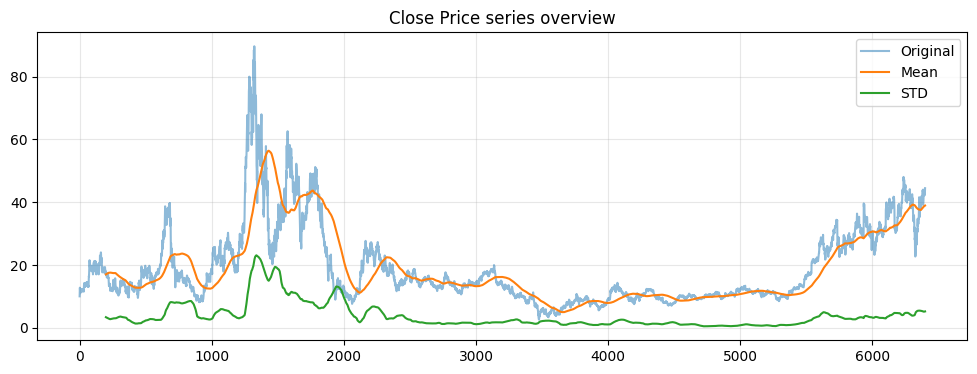

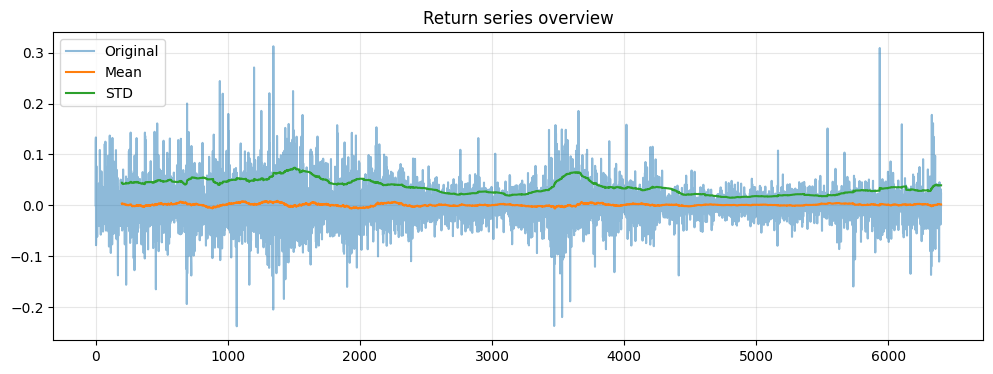

,Series Name,Calculated Stationary State,Expected Stationary State,ADF p,KPSS p
0,Close Price,Non-Stationery,Non-Stationary,0.076583,0.01
1,Return,Stationary,Stationary,0.000000,0.10


In [16]:
# Ignore KPSS interpolation warnings when p-value is outside of available look-up table.
warnings.simplefilter("ignore", InterpolationWarning)

# Dictionary to hold expected stationary results for each series
expected_stationary_states = {
    "Close Price": "Non-Stationary",
    "Return": "Stationary"
}

# Run stationary verification for each series
stationarity_report_df = verify_if_series_stationary(series_data, expected_stationary_states)

# Display stationary report table
stationarity_report_df

The **Close Price** graph shows a clear trend with large fluctuations over time. Its mean and standard deviation also change along with the data, indicating that the series is **not stationary**. This is confirmed by the **ADF** and **KPSS** tests, which support our expected result that the **Close Price** series is non-stationary:
- **ADF p-value**: 0.076583 > 0.05
- **KPSS p-value**: 0.01 < 0.05

In contrast, the **Return** graph fluctuates around zero without a clear trend. The mean stays near zero, and the standard deviation is relatively stable, suggesting the series is **stationary**. The tests confirm this, aligning with our expected result that the **Return** series is stationary:

- **ADF p-value**: 0.0 < 0.05
- **KPSS p-value**: 0.10 > 0.05

---

# 8: Run ARIMA forecasts and evaluate performance

Finally, ARIMA forecasting is applied to each series, and the predictions are evaluated:

- **run_experiment()** – Splits each series into training and testing sets and generates predictions using ARIMA.

- **evaluate_and_plot_graphs()** – Computes evaluation metrics (MSE, RMSE, MAE, directional accuracy, correlation) and plots actual vs. predicted values.

The results for each series are collected in a list and converted into a DataFrame, results_df, for easy comparison.

Forecasting: 100%|██████████| 1280/1280 [02:25<00:00,  8.79it/s]


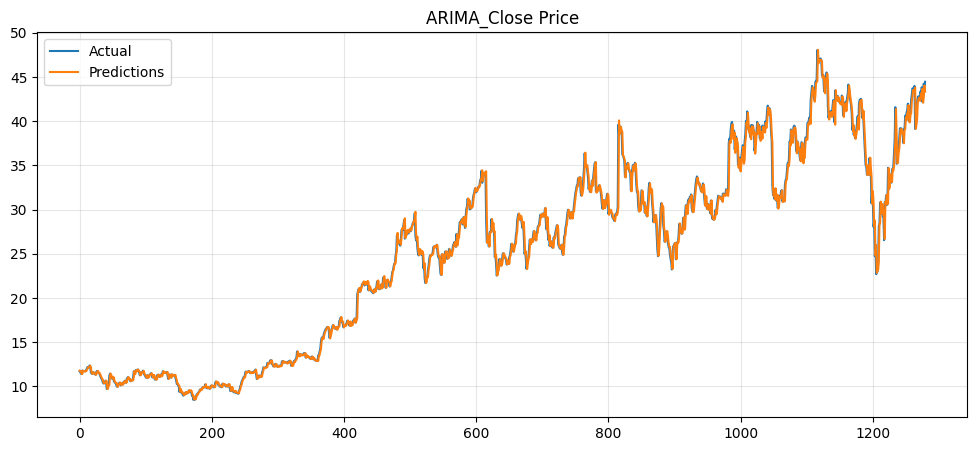

Forecasting: 100%|██████████| 1280/1280 [03:09<00:00,  6.77it/s]


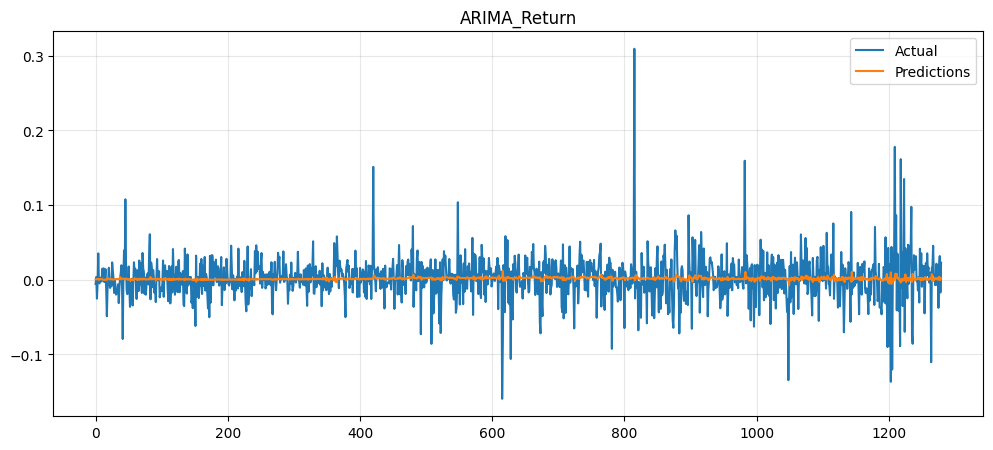

,series,model,mse,rmse,mae,directional_accuracy,correlation
0,Close Price,ARIMA,0.751650,0.866977,0.528473,0.496482,0.996734
1,Return,ARIMA,0.000863,0.029370,0.019644,0.405786,-0.031019


In [17]:
# Ignore ARIMA "ConvergenceWarning: Maximum Likelihood optimization failed to converge." warning
warnings.simplefilter("ignore", ConvergenceWarning)

# List to store results for each series
results = []

# Iterate over all series_data that were created in step "Prep data"
for series_name, series in series_data.items():
    # (p, d, q) parameters for ARIMA
    arima_order = (1, 0, 1)

    # Window for forecasting
    forecast_window = 500

    # Ratio to split the original series into train and test serieses
    train_ratio = 0.8
    
    # Run forecast experiment by calling run_experiment() function
    test, preds = run_experiment(
        series,
        arima_order = arima_order,      
        forecast_window = forecast_window,        
        train_ratio = train_ratio  
    )

    # Creata evaluation metrics and display graphs
    metrics = evaluate_and_plot_graphs(
        test,
        preds,
        f"ARIMA_{series_name}"
    )

    # Save series name, and metrics into results list 
    results.append([series_name,"ARIMA", *metrics])


# Convert results list into a DataFrame 
results_df = pd.DataFrame(
    results,
    columns=["series", "model", "mse", "rmse", "mae", "directional_accuracy", "correlation"]
)

results_df

From the results, we can see that the ARIMA model performs quite differently for **Close Price** and **Returns**.

For the **Close Price**, the **predictions** follow the **actual prices** closely and capture the **overall trend** well. The **MSE** is **0.751650**, the **RMSE** is **0.866977**, and the **MAE** is **0.528473**, which are relatively high. However, the **correlation** is very strong at **0.996734**, showing that the **predicted prices** are almost the same as the **real values**.

Despite this, the **model** struggles to predict the **direction** of **price changes**. With a **directional accuracy** of around **0.496482**, the **model** is basically guessing whether the **price** will go **up or down** each day.

This **high performance** can be **misleading**. As we showed in the previous step, the **Close Price series** is **non-stationary** and has a **clear trend**, so **ARIMA** can follow the **general movement**. While this makes the **predictions** look **accurate**, the **model** does not truly capture **daily changes** and is mostly just following the **trend**.

For the **Return**, the **ARIMA model** produces **different result**. The **predictions** stay almost **flat near zero**, whereas the **actual returns** move **largely up and down**. The **MSE** is **0.000863**, RMSE is **0.029370**, and the **MAE** is **0.019644**, which are quite small, same goes to **weak correlation** at **-0.031019**, which shows that the **predicted returns** are quite different compared to the **real returns**. The **directional accuracy** even smaller compared to the **Close Prices** with **0.405786 for Returns** versus **0.496482 for the Close Prices**.

These results show that **ARIMA cannot effectively predict returns**. Since the **Return series** is **stationary** and fluctuates around **zero** without a **clear trend**, the **model** has no **pattern to follow**, making it unable to capture **short-term movements**.

Therefore, for the GRU multi-modal evaluation, we will use the **stationary Returns** series and aim to improve its performance by incorporating **sentiment analysis**, **macroeconomic states**, **and anomaly detection** into the historical technical data.

---

# 9: Save baseline ARIMA results for Return series

In [18]:
# Filter only returns
return_df = results_df[results_df["series"] == "Return"]

# Save to CSV file
return_df.to_csv("./Outputs/ARIMA_Baseline_with_returns.csv", index=False)